# Notebook 1 — Data Loading & ETF Matching

**Project:** AlphaCast — Sector-Augmented Time-Series Transformers for Financial Forecasting  
**Author:** Paras Beniwal (B.Tech Final Year, Sem-8 Major Project)

## Goal of this notebook
1. Load historical daily OHLCV data for a chosen **target stock** (e.g. `AAPL`, `GOOG`, `JPM`).
2. Load all 9 **SPDR sector ETFs** (XLK, XLF, XLE, XLV, XLY, XLP, XLI, XLB, XLU).
3. Build a **correlation engine** that mathematically picks the single ETF whose daily returns best track the stock.
4. Merge the stock and its matched ETF into one clean dataframe and save to `artifacts/`.

## Why "sector augmentation"?
A single stock's price is noisy — it reacts to earnings, tweets, lawsuits, etc.  
But a **sector ETF** (which holds dozens of similar companies) is a much smoother
signal of the *macro* trend that the stock belongs to. By feeding the model BOTH the
noisy stock AND its stable sector anchor, we give it a stronger signal-to-noise ratio.
This is the central hypothesis of AlphaCast.

In [1]:
# ----------------------------------------------------------------------
# Cell 1 : Imports
# ----------------------------------------------------------------------
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Make plots look reasonable inside the notebook
plt.rcParams['figure.figsize'] = (12, 4)
pd.set_option('display.max_columns', 30)

In [2]:
# ----------------------------------------------------------------------
# Cell 2 : Project paths & configuration
# ----------------------------------------------------------------------
# Resolve project root from the notebook's location (notebooks/ -> ..)
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
DATA_DIR     = os.path.join(PROJECT_ROOT, 'data')
STOCKS_DIR   = os.path.join(DATA_DIR, 'Stocks')
ETFS_DIR     = os.path.join(DATA_DIR, 'ETFs')
ARTIFACTS    = os.path.join(PROJECT_ROOT, 'artifacts')
os.makedirs(ARTIFACTS, exist_ok=True)

# The 9 SPDR sector ETFs are the canonical 'sector buckets' of the US market.
# We restrict our correlation search to these so the matching is interpretable.
SECTOR_ETFS = {
    'XLK': 'Technology',
    'XLF': 'Financials',
    'XLE': 'Energy',
    'XLV': 'Health Care',
    'XLY': 'Consumer Discretionary',
    'XLP': 'Consumer Staples',
    'XLI': 'Industrials',
    'XLB': 'Materials',
    'XLU': 'Utilities',
}

# >>> EDIT ME <<<  -- pick any stock present in data/Stocks/
TARGET_STOCK = 'AAPL'

print('Project root :', PROJECT_ROOT)
print('Target stock :', TARGET_STOCK)

Project root : /Users/parasbeniwal/sem8_project
Target stock : AAPL


In [3]:
# ----------------------------------------------------------------------
# Cell 3 : Generic loader
# ----------------------------------------------------------------------
# The Kaggle 'Huge Stock Market Dataset' files are named like 'aapl.us.txt'
# and contain Date, Open, High, Low, Close, Volume, OpenInt as CSV.

def load_ticker(ticker: str, folder: str) -> pd.DataFrame:
    """Load OHLCV data for a single ticker. Returns a DataFrame indexed by Date."""
    fname = f'{ticker.lower()}.us.txt'
    fpath = os.path.join(folder, fname)
    if not os.path.exists(fpath):
        raise FileNotFoundError(f'No file for {ticker}: {fpath}')

    df = pd.read_csv(fpath, parse_dates=['Date'])
    df = df.sort_values('Date').reset_index(drop=True)
    # 'OpenInt' is always 0 in this dataset — drop it.
    if 'OpenInt' in df.columns:
        df = df.drop(columns=['OpenInt'])
    df = df.set_index('Date')
    return df

# Quick sanity check
stock_df = load_ticker(TARGET_STOCK, STOCKS_DIR)
print(f'{TARGET_STOCK}: {len(stock_df)} rows, {stock_df.index.min().date()} -> {stock_df.index.max().date()}')
stock_df.head()

AAPL: 8364 rows, 1984-09-07 -> 2017-11-10


,Open,High,Low,Close,Volume
Date,,,,,
1984-09-07,0.42388,0.42902,0.41874,0.42388,23220030
1984-09-10,0.42388,0.42516,0.41366,0.42134,18022532
1984-09-11,0.42516,0.43668,0.42516,0.42902,42498199
1984-09-12,0.42902,0.43157,0.41618,0.41618,37125801
1984-09-13,0.43927,0.44052,0.43927,0.43927,57822062


In [4]:
# ----------------------------------------------------------------------
# Cell 4 : Load all sector ETFs into a dict
# ----------------------------------------------------------------------
etf_data = {}
for ticker, sector in SECTOR_ETFS.items():
    try:
        etf_data[ticker] = load_ticker(ticker, ETFS_DIR)
        print(f'  loaded {ticker} ({sector:25s})  rows={len(etf_data[ticker]):5d}  '
              f'from {etf_data[ticker].index.min().date()}')
    except FileNotFoundError as e:
        print('  MISSING:', e)

  loaded XLK (Technology               )  rows= 3201  from 2005-02-25
  loaded XLF (Financials               )  rows= 3201  from 2005-02-25
  loaded XLE (Energy                   )  rows= 3201  from 2005-02-25
  loaded XLV (Health Care              )  rows= 3201  from 2005-02-25
  loaded XLY (Consumer Discretionary   )  rows= 3201  from 2005-02-25
  loaded XLP (Consumer Staples         )  rows= 3201  from 2005-02-25
  loaded XLI (Industrials              )  rows= 3201  from 2005-02-25
  loaded XLB (Materials                )  rows= 3201  from 2005-02-25
  loaded XLU (Utilities                )  rows= 3201  from 2005-02-25


## The Correlation Engine

**Why daily *returns*, not raw price?**  
Two stocks both drifting upward over 10 years will look correlated in price even if
their day-to-day moves are unrelated (this is called *spurious correlation*).  
Daily *returns* (`pct_change`) strip out the long-term drift and measure whether the
two assets actually move together on the same day. That's the right signal for sector
membership.

In [5]:
# ----------------------------------------------------------------------
# Cell 5 : Correlation engine
# ----------------------------------------------------------------------
def find_best_etf(stock_df: pd.DataFrame,
                  etf_dict: dict,
                  price_col: str = 'Close') -> pd.DataFrame:
    """
    For each ETF, compute the Pearson correlation between the stock's daily
    returns and the ETF's daily returns over their overlapping date range.
    Returns a sorted DataFrame.
    """
    stock_ret = stock_df[price_col].pct_change().dropna()
    rows = []
    for etf_ticker, etf_df in etf_dict.items():
        etf_ret = etf_df[price_col].pct_change().dropna()
        # Align on common dates only
        joined = pd.concat([stock_ret, etf_ret], axis=1, join='inner').dropna()
        if len(joined) < 252:   # need at least ~1 year of overlap
            continue
        joined.columns = ['stock', 'etf']
        corr = joined['stock'].corr(joined['etf'])
        rows.append({
            'ETF'      : etf_ticker,
            'Sector'   : SECTOR_ETFS[etf_ticker],
            'Correlation' : round(corr, 4),
            'OverlapDays' : len(joined),
        })
    out = pd.DataFrame(rows).sort_values('Correlation', ascending=False).reset_index(drop=True)
    return out

corr_table = find_best_etf(stock_df, etf_data)
corr_table

,ETF,Sector,Correlation,OverlapDays
0,XLK,Technology,0.6601,3200
1,XLY,Consumer Discretionary,0.5091,3200
2,XLI,Industrials,0.4958,3200
3,XLB,Materials,0.4866,3200
4,XLF,Financials,0.4490,3200
5,XLE,Energy,0.4330,3200
6,XLP,Consumer Staples,0.4124,3200
7,XLV,Health Care,0.3971,3200
8,XLU,Utilities,0.3324,3200


>>> Best sector ETF for AAPL: XLK (Technology) | corr = 0.6601


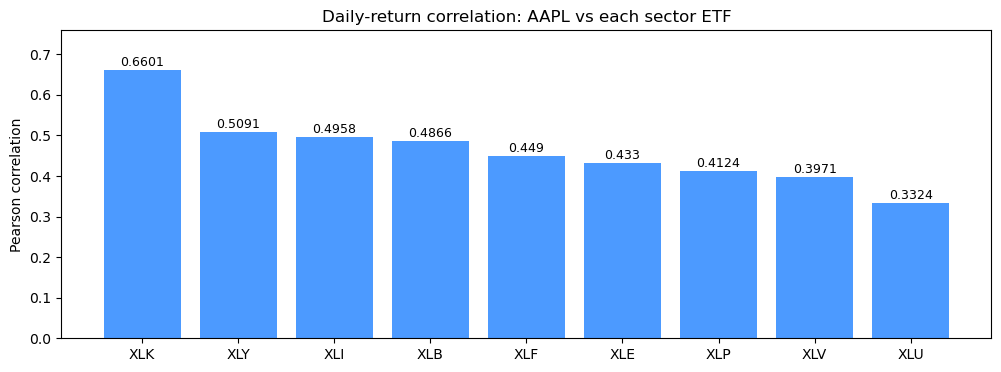

In [6]:
# ----------------------------------------------------------------------
# Cell 6 : Pick the winner & visualise
# ----------------------------------------------------------------------
BEST_ETF    = corr_table.iloc[0]['ETF']
BEST_SECTOR = corr_table.iloc[0]['Sector']
BEST_CORR   = corr_table.iloc[0]['Correlation']
print(f'>>> Best sector ETF for {TARGET_STOCK}: {BEST_ETF} ({BEST_SECTOR}) | corr = {BEST_CORR}')

# Bar chart so we can show this in the report / viva
fig, ax = plt.subplots()
ax.bar(corr_table['ETF'], corr_table['Correlation'], color='#4C9AFF')
ax.set_title(f'Daily-return correlation: {TARGET_STOCK} vs each sector ETF')
ax.set_ylabel('Pearson correlation')
ax.set_ylim(0, max(corr_table['Correlation'])*1.15)
for i, v in enumerate(corr_table['Correlation']):
    ax.text(i, v + 0.01, str(v), ha='center', fontsize=9)
plt.show()

In [7]:
# ----------------------------------------------------------------------
# Cell 7 : Build the merged dataframe (stock + matched-ETF columns)
# ----------------------------------------------------------------------
etf_df = etf_data[BEST_ETF].copy()

# Rename ETF columns so they don't clash with the stock columns
etf_df = etf_df.rename(columns={c: f'ETF_{c}' for c in etf_df.columns})

# Inner join on Date — only keep dates where BOTH stock and ETF traded
merged = stock_df.join(etf_df, how='inner').dropna()
merged = merged.reset_index()

print(f'Merged dataframe shape : {merged.shape}')
print(f'Date range             : {merged.Date.min().date()} -> {merged.Date.max().date()}')
merged.head()

Merged dataframe shape : (3201, 11)
Date range             : 2005-02-25 -> 2017-11-10


,Date,Open,High,Low,Close,Volume,ETF_Open,ETF_High,ETF_Low,ETF_Close,ETF_Volume
0,2005-02-25,5.7411,5.7564,5.6461,5.6975,255345043,17.690,17.834,17.645,17.790,649598
1,2005-02-28,5.7192,5.7807,5.6295,5.7449,182064525,17.755,17.913,17.673,17.736,949704
2,2005-03-01,5.7753,5.7768,5.6553,5.6987,130906953,17.869,17.986,17.817,17.950,670855
3,2005-03-02,5.6653,5.7486,5.6451,5.6499,127769264,17.851,18.038,17.781,17.904,508091
4,2005-03-03,5.6861,5.6871,5.2786,5.3518,393686024,17.878,17.959,17.699,17.772,452526


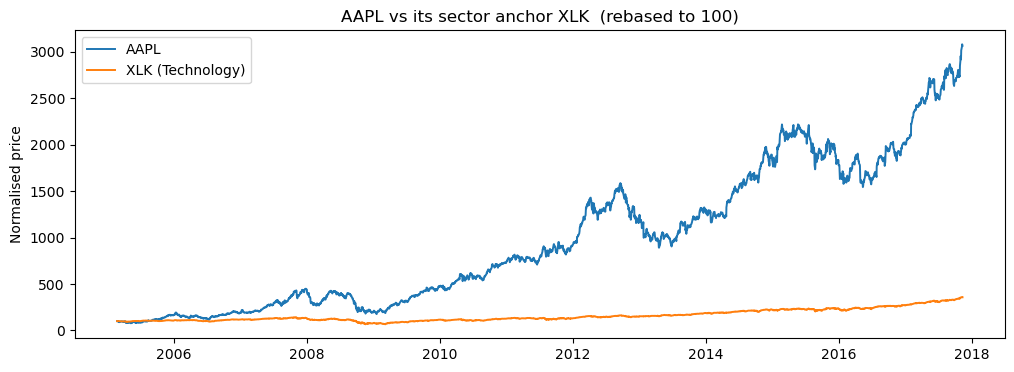

In [8]:
# ----------------------------------------------------------------------
# Cell 8 : Visual sanity check — stock close vs ETF close (normalised)
# ----------------------------------------------------------------------
viz = merged.set_index('Date')[['Close', 'ETF_Close']].copy()
viz = viz / viz.iloc[0] * 100      # rebase both series to 100 on day 1

fig, ax = plt.subplots()
ax.plot(viz.index, viz['Close'],     label=f'{TARGET_STOCK}',  linewidth=1.4)
ax.plot(viz.index, viz['ETF_Close'], label=f'{BEST_ETF} ({BEST_SECTOR})', linewidth=1.4)
ax.set_title(f'{TARGET_STOCK} vs its sector anchor {BEST_ETF}  (rebased to 100)')
ax.set_ylabel('Normalised price')
ax.legend()
plt.show()

In [9]:
# ----------------------------------------------------------------------
# Cell 9 : Persist the merged dataframe + metadata
# ----------------------------------------------------------------------
out_path = os.path.join(ARTIFACTS, f'{TARGET_STOCK}_with_{BEST_ETF}.csv')
merged.to_csv(out_path, index=False)

meta = {
    'stock'       : TARGET_STOCK,
    'matched_etf' : BEST_ETF,
    'sector'      : BEST_SECTOR,
    'correlation' : float(BEST_CORR),
    'rows'        : int(len(merged)),
    'date_start'  : str(merged.Date.min().date()),
    'date_end'    : str(merged.Date.max().date()),
}
import json
with open(os.path.join(ARTIFACTS, f'{TARGET_STOCK}_meta.json'), 'w') as f:
    json.dump(meta, f, indent=2)

print('Saved ->', out_path)
print('Meta  ->', meta)

Saved -> /Users/parasbeniwal/sem8_project/artifacts/AAPL_with_XLK.csv
Meta  -> {'stock': 'AAPL', 'matched_etf': 'XLK', 'sector': 'Technology', 'correlation': 0.6601, 'rows': 3201, 'date_start': '2005-02-25', 'date_end': '2017-11-10'}


## Recap (for the viva)

- We loaded daily OHLCV data for `TARGET_STOCK` and the 9 SPDR sector ETFs.
- We computed the Pearson correlation between the **daily returns** of the stock
  and each ETF — using returns (not raw prices) avoids spurious trend correlation.
- The ETF with the highest correlation is the stock's natural **sector anchor**.
- We saved a single merged CSV `<STOCK>_with_<ETF>.csv` with both price series
  aligned by date — this is the input to Notebook 2 (feature engineering).